In [ ]:
%%capture
!pip install unsloth
!pip install --upgrade "pillow==10.4.0"


In [ ]:
from unsloth import FastModel
import torch

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E4B-it",
    max_seq_length = 1024,
    load_in_4bit = True,
    full_finetuning = False,
)

print("✅ Model loaded!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.7: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

✅ Model loaded!


In [ ]:
from transformers import TextStreamer

def ask_bio(question):
    messages = [{
        "role": "user",
        "content": [{"type": "text", "text": question}]
    }]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize = True,
        return_dict = True,
        return_tensors = "pt",
    ).to("cuda")

    streamer = TextStreamer(tokenizer, skip_prompt=True)

    model.generate(
        **inputs,
        max_new_tokens = 300,
        use_cache = True,
        temperature = 1.0,
        top_p = 0.95,
        top_k = 64,
        streamer = streamer,
    )

ask_bio("මයිටොසිස් සහ මයිඅෝසිස් අතර වෙනස කුමක්ද? ")

මයිටොසිස් (Mitosis) සහ මයිඕසිස් (Meiosis) යන දෙකම සෛල බෙදීම් ක්‍රියාවලීන් වුවද, ඒවායේ අරමුණු, ක්‍රියාවලියේ සංකීර්ණත්වය සහ ප්‍රතිඵලයන්හි විශාල වෙනස්කම් පවතී.

පහත දැක්වෙන්නේ මෙම දෙක අතර ප්‍රධාන වෙනස්කම් සාරාංශගත කළ ආකාරයකි:

---

## 🔬 මයිටොසිස් (Mitosis)

මයිටොසිස් යනු සෛලයක් බෙදී **සමාන (identical)** ද්විත්ව සෛල (daughter cells) දෙකක් හෝ වැඩි ගණනක් නිර්මාණය කරන ක්‍රියාවලියයි.

**ප්‍රධාන ලක්ෂණ:**

1. **අරමුණ:** ශරීරයේ වර්ධනය (Growth), සෛල ප්‍රතිස්ථාපනය (Cell Replacement) සහ පැලෑටිගත වීම (Asexual Reproduction) සඳහා යොදා ගනී.
2. **ක්‍රියාවලියේ සංඛ්‍යාව:** මයිටොසිස් එකක් තුළ **එක් වරක්** පමණක් සෛල බෙදීම සිදු වේ.
3. **ක්‍රෝමොසෝම් සංඛ්‍යාව:** මව් සෛලයට සමාන (2n) සෛල ද


In [ ]:
%%capture
!pip install PyMuPDF pillow

In [ ]:
import fitz
import os

def pdf_to_images(pdf_path, output_folder="bio_pages", zoom=2):
    os.makedirs(output_folder, exist_ok=True)
    doc = fitz.open(pdf_path)

    print(f"📚 Total pages: {len(doc)}")

    saved = []
    for i in range(len(doc)):
        page = doc[i]
        mat = fitz.Matrix(zoom, zoom)
        pix = page.get_pixmap(matrix=mat)
        img_path = f"{output_folder}/page_{i+1:04d}.png"
        pix.save(img_path)
        saved.append(img_path)

        if (i+1) % 50 == 0:
            print(f"✅ {i+1} pages done...")

    print(f"🎉 All {len(saved)} pages saved!")
    return saved


image_paths = pdf_to_images("/content/sGr12OM Biology Resource Book -U01020304.pdf")



📚 Total pages: 169
✅ 50 pages done...
✅ 100 pages done...
✅ 150 pages done...
🎉 All 169 pages saved!


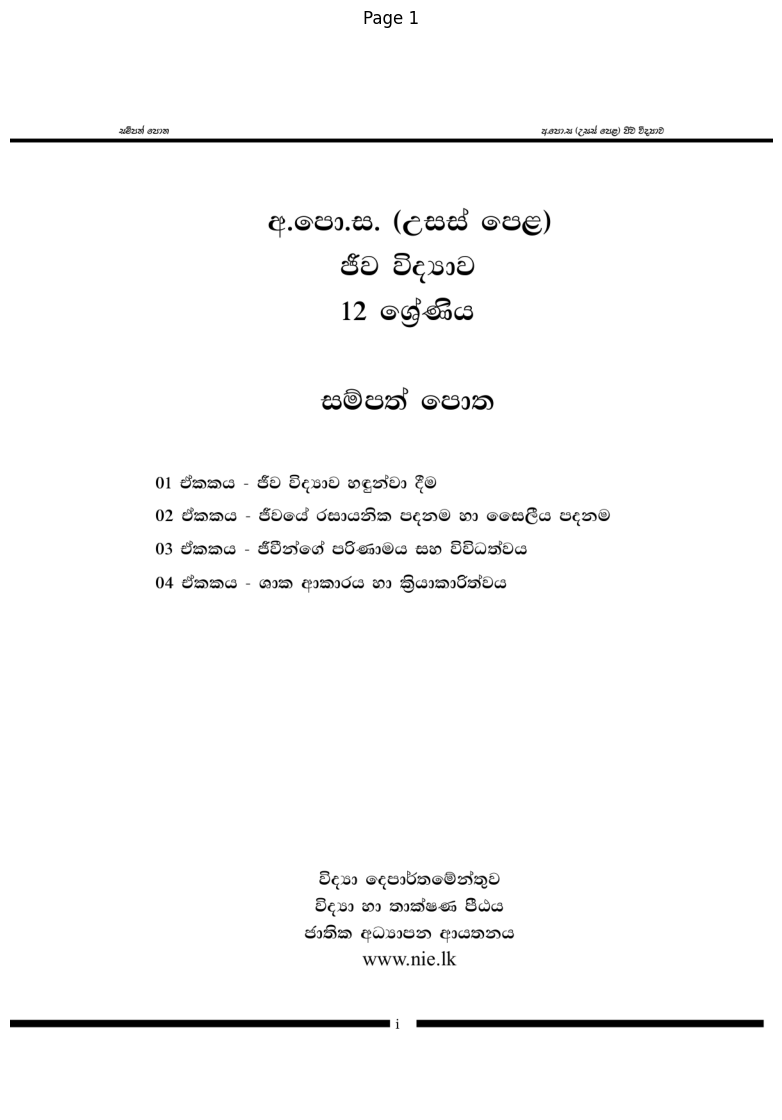

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Page 1 බලන්න
img = Image.open(image_paths[0])
plt.figure(figsize=(10, 14))
plt.imshow(img)
plt.axis('off')
plt.title("Page 1")
plt.show()

In [ ]:
# Step 1: Unsloth import
import unsloth
from unsloth import FastModel
import torch
import os
from PIL import Image

# Step 2: Model load
model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/gemma-4-E4B-it",
    max_seq_length = 2048,
    load_in_4bit = True,
    full_finetuning = False,
)
print("✅ Model loaded!")

# Step 3: Image paths load
image_paths = sorted([
    f"bio_pages/{f}"
    for f in os.listdir("bio_pages")
    if f.endswith(".png")
])
print(f"✅ Found {len(image_paths)} pages")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.7: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

✅ Model loaded!
✅ Found 169 pages


In [ ]:
import json
from PIL import Image
import torch

def generate_explanation_from_page(image_path):

    img = Image.open(image_path)

    prompt = """ඔබ Sri Lanka A/L Biology expert teacher කෙනෙක්.

මේ textbook page එකේ content කියවලා:
1. Main topic එක identify කරන්න
2. ඒ topic සම්පූර්ණයෙන් Sinhala වලින් explain කරන්න
3. Student ට තේරෙන සරල භාෂාවෙන් කියන්න
4. වැදගත් terms bold කරන්න

ONLY මේ page එකේ content ඉඳන් explain කරන්න."""

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": prompt}
        ]
    }]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to("cuda")

    import torch
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1000,
            use_cache=True,
            temperature=1.0,
            top_p=0.95,
            top_k=64,
        )

    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )

# Test — page 9
explanation = generate_explanation_from_page(image_paths[8])
print(explanation)

## Sri Lanka A/L Biology Expert Teacher's Explanation

Hello students! As your A/L Biology expert teacher, I've carefully reviewed the content on this textbook page. Let's break it down step-by-step so you can master this topic.

---

### 1. Main Topic Identification

The main topic of this page is **"Cell Structure and Functions"** (සෛල ව්‍යුහය සහ ක්‍රියාකාරීත්වය).

### 2. Complete Explanation in Sinhala

මෙම පිටුවේ ප්‍රධාන වශයෙන් අවධානය යොමු කරන්නේ **සෛල (Cell)** යනු කුමක්ද, එහි ප්‍රධාන කොටස් මොනවාද, සහ එම කොටස්වල කාර්යයන් මොනවාද යන්න පිළිබඳවයි.

පිටුවේ ආරම්භයේම සඳහන් වන්නේ සෛලයක් යනු ජීවීන්ගේ මූලිකම ඒකකය බවයි. සෛල වර්ග දෙකක් තිබෙන බවත්, ඒවා අතර **ප්‍රෝකරිවොට් සෛල (Prokaryotic cells)** සහ **යුකරිවොට් සෛල (Eukaryotic cells)** යන ඒවා ප්‍රධාන බවත් පැහැදිලි කරයි.

**ප්‍රෝකරිවොට් සෛල** වලදී, සෛලයේ ප්‍රධාන කොටස් (නියුක්ලියස් වැනි) සෛල පටලය තුළම පිහිටා ඇති අතර, ඒවාට සැබෑ **නියුක්ලියස් (Nucleus)** එකක් නොමැත.

**යුකරිවොට් සෛල** වලදී, සෛලයේ ජාන ද්‍රව්‍ය (DNA) ආරක්ෂා කර තබා ගන්නා **සැබෑ නියුක්

In [ ]:
def generate_mcq_from_explanation(topic_explanation, num_q=5):

    prompt = f"""ඔබ Sri Lanka A/L Biology teacher කෙනෙක්.

පහත biology explanation ඉඳන් ONLY exam style MCQ {num_q}ක් හදන්න.
වෙන කිසිවක් add කරන්න එපා.

Explanation:
{topic_explanation}

Format:
Q1: [ප්‍රශ්නය]
A) B) C) D)
පිළිතුර: X
පැහැදිලි කිරීම: [ඇයි මේක නිවැරදිද]
---"""

    messages = [{
        "role": "user",
        "content": [{"type": "text", "text": prompt}]
    }]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to("cuda")

    import torch
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1000,
            use_cache=True,
            temperature=1.0,
            top_p=0.95,
            top_k=64,
        )

    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )

# Test
mcqs = generate_mcq_from_explanation(explanation, num_q=5)
print(mcqs)

Q1: ජීවීන්ගේ මූලිකම ඒකකය ලෙස හඳුන්වනු ලබන්නේ කුමක්ද?
A) අණුව (Molecule)
B) පටලය (Membrane)
C) සෛල (Cell)
D) ප්‍රෝටීන් (Protein)
පිළිතුර: C
පැහැදිලි කිරීම: සෛල යනු සියලුම ජීවීන්ගේ මූලිකම ව්‍යුහාත්මක හා ක්‍රියාකාරී ඒකකයයි.
---
Q2: සෛලයක ජාන ද්‍රව්‍ය (DNA) ආරක්ෂා කර තබා ගන්නා, සැබෑ නියුක්ලියස් එකක් සහිත සෛල වර්ගය කුමක්ද?
A) ප්‍රෝකරිවොට් සෛල
B) සරල සෛල
C) යුකරිවොට් සෛල
D) බැක්ටීරියා සෛල
පිළිතුර: C
පැහැදිලි කිරීම: යුකරිවොට් සෛලවල සැබෑ නියුක්ලියස් එකක් තිබීම විශේෂත්වයකි.
---
Q3: සෛලයේ ශක්තිය (Energy) නිපදවීමට ප්‍රධාන වශයෙන් දායක වන අංගය කුමක්ද?
A) රයිබොසෝම (Ribosome)
B) මයිටොකොන්ඩ්‍රියා (Mitochondria)
C) සෛල පටලය (Cell Membrane)
D) නියුක්ලියස් (Nucleus)
පිළිතුර: B
පැහැදිලි කිරීම: මයිටොකොන්ඩ්‍රියා සෛලයේ ශක්තිය නිපදවන ප්‍රධාන අංගය ලෙස සඳහන් වේ.
---
Q4: සැබෑ නියුක්ලියස් එකක් නොමැති සෛල වර්ගය කුමක්ද?
A) යුකරිවොට් සෛල
B) සංකීර්ණ සෛල
C) ප්‍රෝකරිවොට් සෛල
D) සෛලීය සෛල
පිළිතුර: C
පැහැදිලි කිරීම: ප්‍රෝකරිවොට් සෛලවල සැබෑ නියුක්ලියස් එකක් නොමැත.
---
Q5: පහත සඳහන් අංගයන්ගෙන්, සෛලයේ ක්‍රියාකාරීත්වය සඳහා ව

In [ ]:
import json
import torch
from PIL import Image

def save_to_dataset(user_msg, assistant_msg, filename="bio_dataset.jsonl"):
    entry = {
        "conversations": [
            {"role": "user", "content": user_msg},
            {"role": "assistant", "content": assistant_msg}
        ]
    }
    with open(filename, 'a', encoding='utf-8') as f:
        f.write(json.dumps(entry, ensure_ascii=False) + '\n')


failed_pages = []

for i, img_path in enumerate(image_paths[7:15]):
    page_num = i + 8
    print(f"\n📄 Page {page_num}/{len(image_paths)} processing...")

    try:
        # Step 1: Explanation generate
        exp = generate_explanation_from_page(img_path)

        # Step 2: Explanation save
        save_to_dataset(
            f"AL Biology page {page_num} content explain කරන්න",
            exp
        )

        # Step 3: MCQ generate
        mcq = generate_mcq_from_explanation(exp, num_q=5)

        # Step 4: MCQ save
        save_to_dataset(
            f"AL Biology page {page_num} topic ගැන MCQ 5ක් දෙන්න",
            mcq
        )

        print(f"✅ Page {page_num} done!")

    except Exception as e:
        print(f"❌ Page {page_num} failed: {e}")
        failed_pages.append(page_num)
        continue

print(f"\n🎉 Dataset complete!")
print(f"❌ Failed pages: {failed_pages}")

# Dataset size check
with open("bio_dataset.jsonl", 'r') as f:
    count = sum(1 for line in f)
print(f"📊 Total entries: {count}")


📄 Page 8/169 processing...
✅ Page 8 done!

📄 Page 9/169 processing...
✅ Page 9 done!

📄 Page 10/169 processing...
✅ Page 10 done!

📄 Page 11/169 processing...
✅ Page 11 done!

📄 Page 12/169 processing...
✅ Page 12 done!

📄 Page 13/169 processing...
✅ Page 13 done!

📄 Page 14/169 processing...
✅ Page 14 done!

📄 Page 15/169 processing...
✅ Page 15 done!

🎉 Dataset complete!
❌ Failed pages: []
📊 Total entries: 9


In [ ]:
# Dataset entries check
with open("bio_dataset.jsonl", 'r') as f:
    lines = f.readlines()

print(f"Total entries: {len(lines)}")

# First entry බලන්න
import json
first = json.loads(lines[0])
print("\n--- Entry 1 ---")
print(first['conversations'][0]['content'])  # user message
print("\n--- Assistant ---")
print(first['conversations'][1]['content'][:200])  # first 200 chars

Total entries: 9

--- Entry 1 ---
AL Biology page 8 content explain කරන්න

--- Assistant ---
## Sri Lanka A/L Biology Expert Teacher's Analysis

**Page Content Analysis:**

The provided image is a **Table of Contents (TOC)** for a textbook, not a chapter page containing detailed biological co


In [ ]:
def generate_explanation_from_page(image_path):

    img = Image.open(image_path)

    prompt = """ඔබ Sri Lanka A/L Biology expert teacher කෙනෙක්.

පළමුව මේ page එක check කරන්න:
- මේකේ Table of Contents / Index / විෂය නිර්දේශය / page numbers list තිබෙනවාද?
- Theory content, diagrams, explanations තිබෙනවාද?

Theory content නැත්නම් පළමු line එකේ SKIP ලියන්න.
Theory content තිබෙනවානම් explain කරන්න:

1. Main topic identify කරන්න
2. Sinhala වලින් සම්පූර්ණයෙන් explain කරන්න
3. වැදගත් terms bold කරන්න
4. Student ට සරල භාෂාවෙන් කියන්න

ONLY මේ page එකේ content ඉඳන් explain කරන්න."""

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text", "text": prompt}
        ]
    }]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1000,
            use_cache=True,
            temperature=1.0,
            top_p=0.95,
            top_k=64,
        )

    return tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )


# Loop එකේ SKIP check කරන්න
import json
import torch
from PIL import Image

# Dataset file clear කරන්න (නැවත ආරම්භ කරනවා)
open("bio_dataset.jsonl", 'w').close()

failed_pages = []
skipped_pages = []

for i, img_path in enumerate(image_paths[7:]):
    page_num = i + 8
    print(f"📄 {page_num}/169...", end=" ")

    try:
        exp = generate_explanation_from_page(img_path)

        # SKIP check
        if exp.strip().startswith("SKIP") or exp.strip()[:10].upper().startswith("SKIP"):
            print(f"⏭️ Skipped (TOC/Index)")
            skipped_pages.append(page_num)
            continue

        # Explanation save
        save_to_dataset(
            f"AL Biology page {page_num} explain කරන්න",
            exp
        )

        # MCQ generate + save
        mcq = generate_mcq_from_explanation(exp, num_q=5)
        save_to_dataset(
            f"AL Biology page {page_num} MCQ 5ක් දෙන්න",
            mcq
        )

        print(f"✅")

    except Exception as e:
        print(f"❌ {e}")
        failed_pages.append(page_num)
        continue

# Summary
with open("bio_dataset.jsonl", 'r') as f:
    count = sum(1 for line in f)

print(f"\n🎉 Done!")
print(f"📊 Total entries: {count}")
print(f"⏭️ Skipped pages: {skipped_pages}")
print(f"❌ Failed pages: {failed_pages}")

📄 8/169... ✅
📄 9/169... ✅
📄 10/169... ✅
📄 11/169... ✅
📄 12/169... ✅
📄 13/169... ✅
📄 14/169... ✅
📄 15/169... ✅
📄 16/169... ✅
📄 17/169... ✅
📄 18/169... ✅
📄 19/169... ✅
📄 20/169... ✅
📄 21/169... ✅
📄 22/169... ✅
📄 23/169... ✅
📄 24/169... ✅
📄 25/169... ✅
📄 26/169... ✅
📄 27/169... 

In [ ]:
from google.colab import files
files.download("bio_dataset.jsonl")
